<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/pytorch_tensor_first_steps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch와 텐서 첫걸음 — 1~9 전체 예제

> Source(출처): https://aic-data.aiffel.io/curriculum/02-ml-dl-basics?n=2&course_id=687633e0-68f8-40e8-b352-56f6e8df031b#lesson  
> 정리일: 2026-08-28  
> 원칙: 강의 코드의 줄과 순서는 그대로 보존하고, 앞쪽 주석과 Markdown 설명만 덧붙였습니다.

## Goal(목표)

이 노트북을 끝내면 다음 흐름을 연결해서 설명할 수 있습니다.

**Tensor로 데이터 표현 → Autograd로 Gradient 계산 → torch.nn으로 모델 구성 →
Dataset·DataLoader로 Batch 공급 → Training loop(학습 루프)로 Parameter 업데이트**

의도적 오류, 빈칸 Challenge, Terminal 명령, 덮어쓰기 가능한 File I/O는 실행 셀이 아닌 원문 코드 블록으로 보존합니다.

## Setup(환경 준비)

- Kernel(커널): <code>PRI_AI (Python 3.12.9)</code>
- 필수 Package(패키지): <code>torch</code>, <code>torchvision</code>, <code>numpy</code>, <code>matplotlib</code>
- FashionMNIST를 처음 실행할 때만 Network download(네트워크 다운로드)가 발생합니다.
- 강의 원문은 CUDA가 없으면 CPU를 선택합니다. Mac MPS 확인 코드는 “로컬 보충”으로 별도 유지합니다.

## 1. 들어가며 : PyTorch란 무엇인가

**흐름:** PyTorch의 역할 확인 → 설치 Version(버전) 확인 → CUDA 사용 가능 여부 확인.

PyTorch는 Tensor(텐서)에 숫자를 담아 계산하고, Autograd(자동 미분)로 Gradient(그래디언트)를 구하며,
<code>torch.nn</code>으로 Neural Network(신경망)를 조립하는 Framework(프레임워크)입니다.

### 환경 준비

#### 코드 1값 확인

**예제 흐름:** torch를 불러온 뒤 설치된 Version과 NVIDIA CUDA 사용 가능 여부를 출력합니다.

In [2]:
# 입문자 주석: torch를 불러온 뒤 설치된 Version과 NVIDIA CUDA 사용 가능 여부를 출력합니다.

import torch

print(torch.__version__)          # 설치된 버전 확인
print(torch.cuda.is_available())  # GPU 사용 가능 여부

2.11.0+cu128
True


### 로컬 보충: Mac의 MPS 확인

아래 두 셀은 기존 노트북에 있던 동작을 그대로 보존했습니다.
첫 셀은 강의 환경 확인을 한국어 주석으로 다시 읽고, 둘째 셀은 CUDA → MPS → CPU 순서로 로컬 Device를 고릅니다.
이후 강의 원문 셀이 <code>device</code>를 CUDA 또는 CPU 문자열로 다시 설정하는 것도 원문 흐름 그대로입니다.

In [3]:
# PyTorch 라이브러리를 현재 노트북으로 불러옵니다.
import torch

# 현재 커널에 설치된 PyTorch 버전을 출력합니다.
print(torch.__version__)

# NVIDIA GPU를 사용하는 CUDA가 준비되어 있는지 True/False로 확인합니다.
print(torch.cuda.is_available())

2.11.0+cu128
True


In [4]:
# CUDA(NVIDIA GPU)를 사용할 수 있는지 저장합니다.
cuda_available = torch.cuda.is_available()

# 현재 PyTorch가 MPS(Apple GPU) 기능을 제공하고 실제로 사용할 수 있는지 확인합니다.
mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()

# 사용할 수 있는 가장 빠른 장치를 CUDA → MPS → CPU 순서로 선택합니다.
if cuda_available:
    device = torch.device("cuda")
elif mps_available:
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# 선택 결과를 입문자가 읽기 쉬운 문장으로 출력합니다.
print(f"CUDA 사용 가능: {cuda_available}")
print(f"MPS 사용 가능: {mps_available}")
print(f"이 노트북에서 선택한 장치: {device}")

CUDA 사용 가능: True
MPS 사용 가능: False
이 노트북에서 선택한 장치: cuda


## 2. 텐서란 무엇인가

**흐름:** 차원과 Shape(모양) 확인 → Tensor 생성 → 기본 연산 → NumPy 변환.

Tensor는 숫자를 담는 다차원 상자입니다. 먼저 <code>ndim</code>과 <code>shape</code>를 확인하는 습관을 들이면
이후 Shape mismatch(모양 불일치) 오류를 훨씬 빨리 찾을 수 있습니다.

#### 코드 1값 확인

**예제 흐름:** Scalar(0차원), Vector(1차원), Matrix(2차원)를 만들고 ndim과 shape를 나란히 비교합니다.

In [5]:
# 입문자 주석: Scalar(0차원), Vector(1차원), Matrix(2차원)를 만들고 ndim과 shape를 나란히 비교합니다.

scalar = torch.tensor(36.5)
vector = torch.tensor([85, 90, 78])
matrix = torch.tensor([[85, 90, 78],
                       [70, 88, 95]])

print(scalar.ndim, vector.ndim, matrix.ndim)   # 0 1 2
print(scalar.shape, vector.shape, matrix.shape)

0 1 2
torch.Size([]) torch.Size([3]) torch.Size([2, 3])


### 로컬 보충: Tensor 차원을 한국어 출력으로 다시 확인

기존 노트북의 Scalar·Vector·Matrix 미리보기와 Assertion을 그대로 유지했습니다.

In [6]:
# 숫자 하나를 담은 0차원 Scalar(스칼라) 텐서입니다.
scalar = torch.tensor(36.5)

# 학생 한 명의 세 과목 점수를 담은 1차원 Vector(벡터) 텐서입니다.
vector = torch.tensor([85, 90, 78])

# 학생 두 명의 세 과목 점수를 담은 2차원 Matrix(행렬) 텐서입니다.
matrix = torch.tensor([
    [85, 90, 78],
    [70, 88, 95],
])

# ndim은 차원 수를, shape는 각 축의 크기를 보여 줍니다.
print("차원 수:", scalar.ndim, vector.ndim, matrix.ndim)
print("모양:", scalar.shape, vector.shape, matrix.shape)

차원 수: 0 1 2
모양: torch.Size([]) torch.Size([3]) torch.Size([2, 3])


#### 기존 Assertion(검증식)

여기에서 실행하는 이유는 <code>device</code>가 아직 기존 로컬 코드의 <code>torch.device</code> 객체이고,
Scalar·Vector·Matrix도 바로 앞에서 준비되어 있기 때문입니다.

In [7]:
# Scalar는 0차원이어야 합니다.
assert scalar.ndim == 0

# Vector에는 점수 3개가 있으므로 shape는 (3,)이어야 합니다.
assert vector.shape == (3,)

# Matrix에는 학생 2명과 과목 3개가 있으므로 shape는 (2, 3)이어야 합니다.
assert matrix.shape == (2, 3)

# 선택된 장치는 CPU, CUDA, MPS 중 하나여야 합니다.
assert device.type in {"cpu", "cuda", "mps"}

print("모든 점검을 통과했습니다.")

모든 점검을 통과했습니다.


### 텐서 생성하기

#### 코드 2직접 값을 넣어 생성

**예제 흐름:** 직접 입력, 0·1 채우기, 난수, 범위, 기존 Shape 복사 등 자주 쓰는 생성 방법을 한 번에 봅니다.

In [8]:
# 입문자 주석: 직접 입력, 0·1 채우기, 난수, 범위, 기존 Shape 복사 등 자주 쓰는 생성 방법을 한 번에 봅니다.

# 직접 값을 넣어 생성
a = torch.tensor([1.0, 2.0, 3.0])

# 특정 값으로 채워 생성
zeros = torch.zeros(2, 3)      # 0으로 채운 2x3
ones  = torch.ones(2, 3)       # 1로 채운 2x3
rand  = torch.rand(2, 3)       # 0~1 균등분포 난수
randn = torch.randn(2, 3)      # 표준정규분포 난수

# 범위로 생성
seq = torch.arange(0, 10, 2)   # 0, 2, 4, 6, 8

# 기존 텐서와 같은 shape로 생성
like = torch.zeros_like(rand)

In [9]:
# 바로 위 셀에서 만든 Tensor(텐서) 객체를 확인합니다.
print("a:", a)
print("zeros:", zeros)
print("ones:", ones)
print("rand:", rand)
print("randn:", randn)
print("seq:", seq)
print("like:", like)

a: tensor([1., 2., 3.])
zeros: tensor([[0., 0., 0.],
        [0., 0., 0.]])
ones: tensor([[1., 1., 1.],
        [1., 1., 1.]])
rand: tensor([[0.5151, 0.0113, 0.9073],
        [0.8291, 0.3163, 0.4755]])
randn: tensor([[-0.7960,  0.2990, -0.2484],
        [-2.0033,  2.3102, -0.1012]])
seq: tensor([0, 2, 4, 6, 8])
like: tensor([[0., 0., 0.],
        [0., 0., 0.]])


#### 코드 3값 확인

**예제 흐름:** Random Seed(난수 시드)를 고정해 같은 난수 실험을 다시 만들 수 있게 합니다.

In [10]:
# 입문자 주석: Random Seed(난수 시드)를 고정해 같은 난수 실험을 다시 만들 수 있게 합니다.

torch.manual_seed(42)
print(torch.rand(2))  # 실행할 때마다 같은 값

tensor([0.8823, 0.9150])


In [11]:
# 입문자 주석: Random Seed(난수 시드)를 고정해 같은 난수 실험을 다시 만들 수 있게 합니다.

torch.manual_seed(41)
print(torch.rand(2))  # 실행할 때마다 같은 값

tensor([0.2364, 0.2266])


### 기본 연산

#### 코드 4값 확인

**예제 흐름:** 같은 위치의 원소끼리 더하고 곱하는 Element-wise operation(원소별 연산)을 확인합니다.

In [12]:
# 입문자 주석: 같은 위치의 원소끼리 더하고 곱하는 Element-wise operation(원소별 연산)을 확인합니다.

x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([10.0, 20.0, 30.0])

print(x + y)   # tensor([11., 22., 33.])
print(x * y)   # tensor([10., 40., 90.])  곱셈도 원소끼리
print(x ** 2)  # tensor([1., 4., 9.])

tensor([11., 22., 33.])
tensor([10., 40., 90.])
tensor([1., 4., 9.])


#### 코드 5값 확인

**예제 흐름:** 별표 곱은 원소별 곱이고 @는 행렬 곱이라는 차이를 결과로 비교합니다.

In [13]:
# 입문자 주석: 별표 곱은 원소별 곱이고 @는 행렬 곱이라는 차이를 결과로 비교합니다.

A = torch.tensor([[1., 2.],
                  [3., 4.]])
B = torch.tensor([[5., 6.],
                  [7., 8.]])

print(A * B)   # 원소별 곱
print(A @ B)   # 행렬 곱

tensor([[ 5., 12.],
        [21., 32.]])
tensor([[19., 22.],
        [43., 50.]])


#### 코드 6값 확인

**예제 흐름:** 전체 집계와 dim별 집계를 비교합니다. dim은 그 축을 접어서 없앤다고 읽으면 쉽습니다.

In [14]:
# 입문자 주석: 전체 집계와 dim별 집계를 비교합니다. dim은 그 축을 접어서 없앤다고 읽으면 쉽습니다.

t = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])

print(t.sum())          # 전체 합: 21
print(t.mean())         # 전체 평균: 3.5
print(t.sum(dim=0))     # 열 방향 합: [5., 7., 9.]
print(t.sum(dim=1))     # 행 방향 합: [6., 15.]
print(t.max(), t.argmax())  # 최댓값과 그 위치

tensor(21.)
tensor(3.5000)
tensor([5., 7., 9.])
tensor([ 6., 15.])
tensor(6.) tensor(5)


### NumPy와의 관계

#### 코드 7코드 실행

**예제 흐름:** NumPy Array(배열)를 Tensor로, Tensor를 다시 NumPy로 바꿉니다.

In [15]:
# 입문자 주석: NumPy Array(배열)를 Tensor로, Tensor를 다시 NumPy로 바꿉니다.

import numpy as np

np_arr = np.array([1, 2, 3])
t = torch.from_numpy(np_arr)   # NumPy -> Tensor
back = t.numpy()               # Tensor -> NumPy
print(t)

tensor([1, 2, 3])


#### 코드 8값 확인

**예제 흐름:** 공유 Memory(메모리) 때문에 NumPy 값을 바꾸면 Tensor 값도 함께 바뀌는지 확인합니다.

In [16]:
# 입문자 주석: 공유 Memory(메모리) 때문에 NumPy 값을 바꾸면 Tensor 값도 함께 바뀌는지 확인합니다.

np_arr[0] = 100
print(t)   # tensor([100, 2, 3])  같이 바뀜

tensor([100,   2,   3])


### 실습: Tensor 만들고 조작하기
1. 3×4 Zero Tensor를 만들고 Shape를 출력합니다.
2. 0부터 20까지 4씩 증가하는 Tensor를 만듭니다.
3. <code>torch.manual_seed(0)</code> 뒤 2×2 Random Tensor를 만듭니다.
4. 문제 3 결과에 10을 곱합니다.

In [17]:
import torch
import numpy as np

# 1
x = torch.zeros(3, 4)
print(x.shape)

# 2  (arange는 끝값 미포함! 20을 포함하려면 끝을 뭘로?)
print(torch.arange(0, 21, 4))

# 3
torch.manual_seed(0)
r = torch.rand(2, 2)
print(r)

# 4
print(r * 10)

torch.Size([3, 4])
tensor([ 0,  4,  8, 12, 16, 20])
tensor([[0.4963, 0.7682],
        [0.0885, 0.1320]])
tensor([[4.9626, 7.6822],
        [0.8848, 1.3203]])


5. 두 2×2 Tensor의 원소별 곱과 행렬 곱을 각각 구합니다.
6. 3×3 Random Tensor의 전체·행별·열별 평균을 구합니다.
7. <code>[3, 1, 4, 1, 5, 9, 2, 6]</code>의 최댓값과 Index를 구합니다.

In [18]:
# 5
A = torch.tensor([[1, 2], [3, 4]])
B = torch.tensor([[5, 6], [7, 8]])
print(A * B)   # 원소별
print(A @ B)   # 행렬 곱

tensor([[ 5, 12],
        [21, 32]])
tensor([[19, 22],
        [43, 50]])


In [19]:
# 6
m = torch.rand(2, 3)
mm = torch.randn(2, 3)

print(mm)
print(mm.mean())
print(mm.mean(dim=1) )
print(mm.mean(dim=0))


print(m)
print(m.mean())
print(m.mean(dim=1))   # 행별
print(m.mean(dim=0))   # 열별

tensor([[ 0.1604, -0.6065, -0.7831],
        [ 1.0622, -0.2613,  1.0667]])
tensor(0.1064)
tensor([-0.4097,  0.6225])
tensor([ 0.6113, -0.4339,  0.1418])
tensor([[0.3074, 0.6341, 0.4901],
        [0.8964, 0.4556, 0.6323]])
tensor(0.5693)
tensor([0.4772, 0.6615])
tensor([0.6019, 0.5449, 0.5612])


In [20]:
# 7
v = torch.tensor([3, 1, 4, 1, 5, 9, 2, 6])
print(v.max(), v.argmax())

tensor(9) tensor(5)


8. NumPy <code>[10, 20, 30]</code>을 Tensor로 바꾸고 공유 Memory를 확인합니다.
9. 문제 8을 공유 Memory 없이 복사해 다시 확인합니다.
10. Shape (2, 3)과 (3, 2)의 행렬 곱 결과 Shape를 예측한 뒤 확인합니다.

In [21]:
# 8
arr = np.array([10, 20, 30])
t = torch.from_numpy(arr)
arr[0] = 100
print(t)

tensor([100,  20,  30])


In [22]:
# 9  (메모리 분리)
t2 = torch.from_numpy(arr.copy())
print(t2)

tensor([100,  20,  30])


In [23]:
# 10  예측: (2,3)@(3,2) → shape는? 먼저 적어보고
print((torch.rand(2, 3) @ torch.rand(3, 2)).shape)

torch.Size([2, 2])


### Quiz 1(퀴즈 1)

1. Shape (4, 5)에서 <code>sum(dim=0)</code> 결과 Shape는? → **(5,)**
2. <code>rand</code>와 <code>randn</code> 차이는? → **0~1 Uniform distribution(균등분포) / 평균 0·표준편차 1 Normal distribution(정규분포)**
3. <code>A * B</code>와 <code>A @ B</code> 차이는? → **원소별 곱 / 행렬 곱**
4. <code>from_numpy</code> Tensor의 특징은? → **원본 NumPy와 Memory 공유**
5. 컬러 이미지 32장 Batch는 몇 차원? → **4차원: (Batch, Channel, Height, Width)**

## 3. 텐서 다루기 심화

**흐름:** 일부 값 선택 → Shape 변경 → 결합·분할 → Broadcasting(브로드캐스팅) → dtype·Device(장치).

핵심 질문은 항상 두 가지입니다. “지금 Shape가 무엇인가?”, “다음 연산 뒤 Shape가 어떻게 바뀌는가?”

### 인덱싱과 슬라이싱

#### 코드 1값 확인

**예제 흐름:** 행, 열, 범위, 마지막 행을 고르는 Indexing(인덱싱)과 Slicing(슬라이싱)을 연습합니다.

In [24]:
# 입문자 주석: 행, 열, 범위, 마지막 행을 고르는 Indexing(인덱싱)과 Slicing(슬라이싱)을 연습합니다.

t = torch.arange(12).reshape(3, 4)
# tensor([[ 0,  1,  2,  3],
#         [ 4,  5,  6,  7],
#         [ 8,  9, 10, 11]])
print(t)
print(t[0])        # 첫 번째 행
print(t[0, 2])     # 0행 2열의 원소: 2
print(t[:, 1])     # 모든 행의 1열: [1, 5, 9]
print(t[1:, 2:])   # 1행 이후, 2열 이후
print(t[-1])       # 마지막 행

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
tensor([0, 1, 2, 3])
tensor(2)
tensor([1, 5, 9])
tensor([[ 6,  7],
        [10, 11]])
tensor([ 8,  9, 10, 11])


#### 코드 2값 확인

**예제 흐름:** 조건식이 만든 Boolean Mask(불리언 마스크)로 5보다 큰 값만 고릅니다.

In [25]:
# 입문자 주석: 조건식이 만든 Boolean Mask(불리언 마스크)로 5보다 큰 값만 고릅니다.

print(t[t > 5])    # 5보다 큰 원소만: [ 6,  7,  8,  9, 10, 11]

tensor([ 6,  7,  8,  9, 10, 11])


### reshape, view, permute

#### 코드 3코드 실행

**예제 흐름:** 원소 수 12개를 유지하면서 여러 Shape로 reshape하고 -1 자동 계산을 확인합니다.

In [26]:
# 입문자 주석: 원소 수 12개를 유지하면서 여러 Shape로 reshape하고 -1 자동 계산을 확인합니다.

t = torch.arange(12)
a = t.reshape(3, 4)
b = t.reshape(2, 6)
c = t.reshape(4, -1)   # -1은 "알아서 계산해줘": (4, 3)이 됨

print(t)
print(a)
print(b)
print(c)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])


#### 코드 4값 확인

**예제 흐름:** 이미지 축 순서를 Channel-Height-Width에서 Height-Width-Channel로 바꿉니다.

In [27]:
# 입문자 주석: 이미지 축 순서를 Channel-Height-Width에서 Height-Width-Channel로 바꿉니다.

img = torch.rand(3, 2, 4)       # (채널, 높이, 너비)
hwc = img.permute(1, 2, 0)          # (높이, 너비, 채널)로 순서 변경
print(img.shape)
print(hwc.shape)                    # torch.Size([224, 224, 3])

print(img)

print(hwc)

torch.Size([3, 2, 4])
torch.Size([2, 4, 3])
tensor([[[0.1507, 0.0317, 0.2081, 0.9298],
         [0.7231, 0.7423, 0.5263, 0.2437]],

        [[0.5846, 0.0332, 0.1387, 0.2422],
         [0.8155, 0.7932, 0.2783, 0.4820]],

        [[0.8198, 0.9971, 0.6984, 0.5675],
         [0.8352, 0.2056, 0.5932, 0.1123]]])
tensor([[[0.1507, 0.5846, 0.8198],
         [0.0317, 0.0332, 0.9971],
         [0.2081, 0.1387, 0.6984],
         [0.9298, 0.2422, 0.5675]],

        [[0.7231, 0.8155, 0.8352],
         [0.7423, 0.7932, 0.2056],
         [0.5263, 0.2783, 0.5932],
         [0.2437, 0.4820, 0.1123]]])


#### 코드 5값 확인

**예제 흐름:** reshape는 읽는 순서를 유지하고 permute는 축 순서를 실제로 바꾼다는 차이를 비교합니다.

In [28]:
# 입문자 주석: reshape는 읽는 순서를 유지하고 permute는 축 순서를 실제로 바꾼다는 차이를 비교합니다.

t = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])
print(t.reshape(3, 2))   # [[1,2],[3,4],[5,6]]  읽는 순서 유지
print(t.permute(1, 0))   # [[1,4],[2,5],[3,6]]  행과 열이 뒤집힘

tensor([[1, 2],
        [3, 4],
        [5, 6]])
tensor([[1, 4],
        [2, 5],
        [3, 6]])


#### 코드 6코드 실행

**예제 흐름:** unsqueeze는 크기 1인 축을 추가하고 squeeze는 그 축을 제거합니다.

In [29]:
# 입문자 주석: unsqueeze는 크기 1인 축을 추가하고 squeeze는 그 축을 제거합니다.

t = torch.rand(3, 4)
t2 = t.unsqueeze(0)    # (1, 3, 4)  배치 차원 추가에 자주 사용
t3 = t2.squeeze(0)     # 다시 (3, 4)

In [30]:
# unsqueeze와 squeeze 전후의 Shape(모양)를 비교합니다.
print("t:", t.shape)
print("t2 (unsqueeze):", t2)
print("t2 (unsqueeze):", t2.shape)
print("t3 (squeeze):", t3)
print("t3 (squeeze):", t3.shape)

t: torch.Size([3, 4])
t2 (unsqueeze): tensor([[[0.1535, 0.2417, 0.7262, 0.7011],
         [0.2038, 0.6511, 0.7745, 0.4369],
         [0.5191, 0.6159, 0.8102, 0.9801]]])
t2 (unsqueeze): torch.Size([1, 3, 4])
t3 (squeeze): tensor([[0.1535, 0.2417, 0.7262, 0.7011],
        [0.2038, 0.6511, 0.7745, 0.4369],
        [0.5191, 0.6159, 0.8102, 0.9801]])
t3 (squeeze): torch.Size([3, 4])


### 텐서 붙이기와 나누기

#### 코드 7코드 실행

**예제 흐름:** cat은 기존 축을 따라 붙이고 stack은 새 축을 만든다는 Shape 차이를 봅니다.

In [31]:
# 입문자 주석: cat은 기존 축을 따라 붙이고 stack은 새 축을 만든다는 Shape 차이를 봅니다.

a = torch.rand(2, 3)
b = torch.rand(2, 3)

cat0 = torch.cat([a, b], dim=0)     # (4, 3)  행 방향으로 이어붙임
cat1 = torch.cat([a, b], dim=1)     # (2, 6)  열 방향으로 이어붙임
stacked = torch.stack([a, b])       # (2, 2, 3)  새 차원이 생김

In [32]:
# cat과 stack 결과의 Shape(모양)를 비교합니다.
print("a:", a.shape, "b:", b.shape)
print("cat0:", cat0.shape)
print("cat1:", cat1.shape)
print("stacked:", stacked.shape)
print("a:", a, "b:", b)
print("stacked:", stacked)

a: torch.Size([2, 3]) b: torch.Size([2, 3])
cat0: torch.Size([4, 3])
cat1: torch.Size([2, 6])
stacked: torch.Size([2, 2, 3])
a: tensor([[0.1147, 0.3168, 0.6965],
        [0.9143, 0.9351, 0.9412]]) b: tensor([[0.5995, 0.0652, 0.5460],
        [0.1872, 0.0340, 0.9442]])
stacked: tensor([[[0.1147, 0.3168, 0.6965],
         [0.9143, 0.9351, 0.9412]],

        [[0.5995, 0.0652, 0.5460],
         [0.1872, 0.0340, 0.9442]]])


#### 코드 8값 확인

**예제 흐름:** chunk는 덩어리 수로, split은 각 덩어리 크기로 Tensor를 나눕니다.

In [33]:
# 입문자 주석: chunk는 덩어리 수로, split은 각 덩어리 크기로 Tensor를 나눕니다.

t = torch.arange(10)
print(t)
print(torch.chunk(t, 2))       # 5개씩 2덩어리
print(torch.chunk(t, 3))       # 5개씩 3덩어리
print(torch.split(t, 2))
print(torch.split(t, [3, 7]))  # 3개, 7개로 분할

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
(tensor([0, 1, 2, 3, 4]), tensor([5, 6, 7, 8, 9]))
(tensor([0, 1, 2, 3]), tensor([4, 5, 6, 7]), tensor([8, 9]))
(tensor([0, 1]), tensor([2, 3]), tensor([4, 5]), tensor([6, 7]), tensor([8, 9]))
(tensor([0, 1, 2]), tensor([3, 4, 5, 6, 7, 8, 9]))


### 브로드캐스팅

#### 코드 9값 확인

**예제 흐름:** 작은 값이나 Vector가 큰 Tensor Shape에 맞춰 자동 확장되는 Broadcasting을 확인합니다.

In [34]:
# 입문자 주석: 작은 값이나 Vector가 큰 Tensor Shape에 맞춰 자동 확장되는 Broadcasting을 확인합니다.

t = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])   # (2, 3)

print(t + 10)                       # 스칼라가 (2, 3)으로 확장
print(t + torch.tensor([10., 20., 30.]))   # (3,)이 (2, 3)으로 확장

tensor([[11., 12., 13.],
        [14., 15., 16.]])
tensor([[11., 22., 33.],
        [14., 25., 36.]])


#### 코드 10직접 해

**예제 흐름:** (2, 3)과 (3, 2)는 어느 뒤쪽 축도 맞지 않아 더할 수 없습니다. 오류 줄은 주석이라 안전하게 실행됩니다.

In [35]:
# 입문자 주석: (2, 3)과 (3, 2)는 어느 뒤쪽 축도 맞지 않아 더할 수 없습니다. 오류 줄은 주석이라 안전하게 실행됩니다.

a = torch.rand(2, 3)
b = torch.rand(3, 2)
# a + b   # RuntimeError! 직접 실행해서 에러 메시지를 읽어 보세요

print(a+b)

RuntimeError: The size of tensor a (3) must match the size of tensor b (2) at non-singleton dimension 1

In [ ]:
# Broadcasting(브로드캐스팅)이 실패하는 두 Tensor의 Shape를 확인합니다.
print("a.shape:", a.shape)
print("b.shape:", b.shape)

### 텐서의 dtype

#### 코드 11값 확인

**예제 흐름:** 정수 입력은 int64, 소수 입력은 float32가 되는 기본 dtype을 확인합니다.

In [ ]:
# 입문자 주석: 정수 입력은 int64, 소수 입력은 float32가 되는 기본 dtype을 확인합니다.

a = torch.tensor([1, 2, 3])        # int64
b = torch.tensor([1., 2., 3.])     # float32
print(a.dtype, b.dtype)

#### 코드 12코드 실행

**예제 흐름:** 모델 입력과 연산 규칙에 맞게 dtype을 명시적으로 변환합니다.

In [ ]:
# 입문자 주석: 모델 입력과 연산 규칙에 맞게 dtype을 명시적으로 변환합니다.

c = a.float()            # int64 -> float32
d = b.to(torch.int64)    # float32 -> int64

In [ ]:
# dtype 변환 뒤 값과 자료형을 함께 확인합니다.
print("c:", c, "| dtype:", c.dtype)
print("d:", d, "| dtype:", d.dtype)

### CPU와 GPU

#### 코드 13값 확인

**예제 흐름:** CUDA가 있으면 GPU, 없으면 CPU를 선택하고 Tensor를 같은 Device로 옮깁니다.

In [ ]:
# 입문자 주석: CUDA가 있으면 GPU, 없으면 CPU를 선택하고 Tensor를 같은 Device로 옮깁니다.

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

t = torch.rand(3, 3)
t_gpu = t.to(device)      # GPU로 이동
print(t_gpu.device)

#### 코드 14코드 실행

**예제 흐름:** 서로 다른 Device의 Tensor는 연산할 수 없습니다. 오류 줄이 주석 처리된 설명용 예제입니다.

In [ ]:
# 입문자 주석: 서로 다른 Device의 Tensor는 연산할 수 없습니다. 오류 줄이 주석 처리된 설명용 예제입니다.

a = torch.rand(2, 2)               # CPU
b = torch.rand(2, 2).to(device)    # GPU
# a + b   # RuntimeError: Expected all tensors to be on the same device

In [ ]:
# 두 Tensor가 실제로 어느 Device(장치)에 있는지 확인합니다.
print("a.device:", a.device)
print("b.device:", b.device)
print("같은 Device인가?:", a.device == b.device)

In [ ]:
print(torch.backends.mps.is_available())

#### 코드 15코드 실행

**예제 흐름:** GPU Tensor는 먼저 CPU로 가져온 뒤 NumPy Array로 바꿔야 합니다.

In [ ]:
# 입문자 주석: GPU Tensor는 먼저 CPU로 가져온 뒤 NumPy Array로 바꿔야 합니다.

arr = t_gpu.cpu().numpy()

In [ ]:
# Tensor에서 변환된 NumPy Array(배열)의 객체·형식·Shape를 확인합니다.
print("arr type:", type(arr))
print("arr shape:", arr.shape)
print("arr:", arr)

#### 코드 16값 확인

**예제 흐름:** 같은 큰 행렬 곱을 CPU와 사용 가능한 GPU 가속기(CUDA 또는 Mac MPS)에서 재어 Device(장치)별 시간을 비교합니다. GPU 연산은 asynchronous(비동기)일 수 있으므로 synchronize(동기화)한 뒤 시간을 확인하며, 가속기를 사용할 수 없으면 CPU만 측정합니다. 시간은 1회 측정값이라 실행할 때마다 달라질 수 있습니다.

In [ ]:
# 입문자 주석: 같은 큰 행렬 곱을 CPU와 CUDA 또는 Mac MPS에서 재어 Device별 시간을 비교합니다.

import time

size = 4096
a_cpu = torch.rand(size, size)
b_cpu = torch.rand(size, size)

start = time.perf_counter()
_ = a_cpu @ b_cpu
print(f"CPU: {time.perf_counter() - start:.3f}초")

# 기존 CUDA를 우선 사용하고, CUDA가 없는 Mac에서는 MPS를 선택합니다.
if torch.cuda.is_available():
    accelerator = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    accelerator = torch.device("mps")
else:
    accelerator = None

if accelerator is not None:
    a_accelerator = a_cpu.to(accelerator)
    b_accelerator = b_cpu.to(accelerator)
    _ = a_accelerator @ b_accelerator  # GPU 워밍업

    # GPU 연산이 끝난 뒤 측정을 시작하도록 Device별로 동기화합니다.
    if accelerator.type == "mps":
        torch.mps.synchronize()
    else:
        torch.cuda.synchronize()

    start = time.perf_counter()
    _ = a_accelerator @ b_accelerator

    # 비동기 행렬 곱이 실제로 끝날 때까지 기다린 뒤 경과 시간을 출력합니다.
    if accelerator.type == "mps":
        torch.mps.synchronize()
    else:
        torch.cuda.synchronize()

    print(f"{accelerator.type.upper()}: {time.perf_counter() - start:.3f}초")
else:
    print("사용 가능한 GPU 가속기(CUDA/MPS)가 없어 CPU만 측정했습니다.")

### 실습. shape 퍼즐

#### 원문 예제 26

> 자동 실행 제외: 강의가 의도한 Shape 오류 예제. 원문은 그대로 보존했습니다.

```python
a = torch.rand(2, 3)
b = torch.rand(4, 3)
c = torch.cat([a, b], dim=1)

```

**입문자 설명:** cat의 dim=1은 행 수가 같아야 하지만 2와 4라서 오류가 납니다. dim=0으로 붙이거나 Shape를 맞춰야 합니다.

#### 원문 예제 27

> 자동 실행 제외: 강의가 의도한 dtype 오류 예제. 원문은 그대로 보존했습니다.

```python
weights = torch.rand(3)
counts = torch.tensor([1, 2, 3])
result = weights @ counts

```

**입문자 설명:** weights는 float32, counts는 int64라 행렬 곱 dtype이 다릅니다. counts.float()로 맞추면 됩니다.

### 실습: Shape 퍼즐

1. <code>torch.arange(24)</code>를 (2, 3, 4)로 reshape합니다.
2. 마지막 축의 평균과 결과 Shape를 예측합니다.
3. (3, 224, 224)를 (224, 224, 3)으로 permute합니다.
4. (2, 3) Tensor 두 개를 stack해 (2, 2, 3), cat해 (4, 3)을 만듭니다.
5. 위의 의도적 cat 오류 원인을 설명하고 고칩니다.
6. (5, 1)과 (1, 4)의 Broadcasting 결과 Shape를 예측합니다.
7. 위의 dtype 오류를 float32로 맞춰 고칩니다.
8. (3, 4) Tensor를 GPU로 보냈다가 CPU NumPy로 되돌립니다.
9. (3, 4)에 unsqueeze(0), unsqueeze(1), unsqueeze(-1)을 적용한 Shape를 예측합니다.
10. 흑백 이미지 Batch (32, 28, 28)를 (32, 784)로 Flatten(평탄화)합니다.

### Quiz 2(퀴즈 2)

1. reshape와 permute의 차이 → **Shape만 변경 / 축 순서 변경**
2. cat과 stack의 차이 → **기존 축 연결 / 새 축 추가**
3. (4, 1) + (3,) 결과 Shape → **(4, 3)**
4. Deep Learning 기본 dtype → **float32**
5. Device mismatch 해결 → **모델과 모든 Tensor를 같은 Device로 이동**

## 4. Autograd, 미분을 자동으로

**흐름:** 미분 추적 켜기 → <code>backward()</code>로 Gradient 계산 → 추적 끄기 → Gradient 누적 이해 → 한 번의 학습 반복.

Autograd는 Loss(손실)가 줄어드는 방향을 찾기 위해 각 Parameter(파라미터)의 미분값을 자동으로 계산합니다.

### requires_grad, backward, grad

#### 코드 1값 확인

**예제 흐름:** x=3에서 y=x²의 미분 2x=6을 Autograd가 계산하는 가장 작은 예제입니다.

In [ ]:
# 입문자 주석: x=3에서 y=x²의 미분 2x=6을 Autograd가 계산하는 가장 작은 예제입니다.

x = torch.tensor(3.0, requires_grad=True)
y = x ** 2          # y = x^2

y.backward()        # dy/dx 계산
print(x.grad)       # tensor(6.)  = 2x = 2*3

#### 코드 2값 확인

**예제 흐름:** 선형식 y=wx+b에서 w와 b 각각에 대한 Gradient를 한 번의 backward로 구합니다.

In [ ]:
# 입문자 주석: 선형식 y=wx+b에서 w와 b 각각에 대한 Gradient를 한 번의 backward로 구합니다.

w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(4.0)                 # 입력 데이터는 추적 불필요

y = w * x + b                         # y = 2*4 + 1 = 9
y.backward()

print(w.grad)   # tensor(4.)  dy/dw = x = 4
print(b.grad)   # tensor(1.)  dy/db = 1

#### 코드 3값 확인

**예제 흐름:** 여러 원소의 결과를 sum으로 Scalar(스칼라) 하나로 만든 뒤 backward를 호출합니다.

In [ ]:
# 입문자 주석: 여러 원소의 결과를 sum으로 Scalar(스칼라) 하나로 만든 뒤 backward를 호출합니다.

x = torch.rand(3, requires_grad=True)
y = (x ** 2).sum()    # sum으로 스칼라를 만든 뒤

print(y)
y.backward()          # backward 호출
print(x.grad)         # 2x와 일치

### 그래디언트 추적 끄기

#### 코드 4값 확인

**예제 흐름:** no_grad 블록 안에서는 계산 그래프를 만들지 않아 평가와 예측이 가벼워집니다.

In [ ]:
# 입문자 주석: no_grad 블록 안에서는 계산 그래프를 만들지 않아 평가와 예측이 가벼워집니다.

x = torch.tensor(3.0, requires_grad=True)

with torch.no_grad():
    y = x ** 2
print(y.requires_grad)   # False. 이 블록 안의 연산은 기록되지 않음

#### 코드 5코드 실행

**예제 흐름:** detach는 값은 유지하면서 현재 Tensor를 계산 그래프에서 분리합니다.

In [ ]:
# 입문자 주석: detach는 값은 유지하면서 현재 Tensor를 계산 그래프에서 분리합니다.

z = x ** 2
z_detached = z.detach()   # 값은 같지만 그래프와 연결이 끊긴 텐서

In [ ]:
# detach 전후의 값과 Gradient(그래디언트) 추적 상태를 비교합니다.
print("z:", z, "| requires_grad:", z.requires_grad)
print("z_detached:", z_detached, "| requires_grad:", z_detached.requires_grad)

### 그래디언트는 누적된다

#### 코드 6값 확인

**예제 흐름:** backward를 반복하면 Gradient가 덮어써지지 않고 더해진다는 누적 동작을 확인합니다.

In [ ]:
# 입문자 주석: backward를 반복하면 Gradient가 덮어써지지 않고 더해진다는 누적 동작을 확인합니다.

x = torch.tensor(3.0, requires_grad=True)

y1 = x ** 2
y1.backward()
print(x.grad)   # tensor(6.)

y2 = x ** 2
y2.backward()
print(x.grad)   # tensor(12.)  6이 아니라 6+6!

x.grad.zero_()
y3 = x ** 2
y3.backward()
print(x.grad)

#### 코드 7코드 실행

**예제 흐름:** zero_로 누적된 Gradient를 0으로 되돌립니다.

In [ ]:
# 입문자 주석: zero_로 누적된 Gradient를 0으로 되돌립니다.

x.grad.zero_()   # grad를 0으로 초기화

### 미리 보기: 경사하강법 한 스텝

#### 코드 8값 확인

**예제 흐름:** 예측 → Loss → backward → Parameter update → Gradient 초기화를 1000번 반복해 w=3, b=2에 접근합니다.

In [ ]:
# 입문자 주석: 예측 → Loss → backward → Parameter update → Gradient 초기화를 1000번 반복해 w=3, b=2에 접근합니다.

import matplotlib.pyplot as plt

# 정답이 y = 3x + 2인 데이터 초기 설정
x_data = torch.tensor([1.0, 2.0, 3.0, 4.0])
y_data = torch.tensor([5.0, 8.0, 11.0, 14.0])

# 아무 값으로 시작
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
lr = 0.0001   # 학습률: 한 걸음의 크기

# --- 시각화를 위해 값을 저장할 빈 리스트 생성 ---
loss_history = []
w_history = []
b_history = []

# 모델 학습
for step in range(1000):
    y_pred = w * x_data + b               # 1. 예측 (forward)
    loss = ((y_pred - y_data) ** 2).mean()  # 2. 손실 계산

    loss.backward()                       # 3. 미분 계산 (backward)

    with torch.no_grad():                 # 4. 파라미터 업데이트
        w -= lr * w.grad
        b -= lr * b.grad

# --- 현재 스텝의 값들을 리스트에 저장 (.item()을 써서 파이썬 숫자로 변환) ---
    loss_history.append(loss.item())
    w_history.append(w.item())
    b_history.append(b.item())

    w.grad.zero_()                        # 5. 그래디언트 초기화
    b.grad.zero_()

    if step % 50 == 0:
        print(f"step {step}: loss={loss.item():.4f}, w={w.item():.3f}, b={b.item():.3f}")

print(f"최종: w={w.item():.3f}, b={b.item():.3f}")   # w은3, b는2에 점차 가까워짐

#### 코드 9그래프 시각화

**예제 흐름:** Loss 감소, w·b 수렴, 최종 회귀선을 세 그래프로 연결해 학습 과정을 눈으로 확인합니다.

In [ ]:
# 입문자 주석: Loss 감소, w·b 수렴, 최종 회귀선을 세 그래프로 연결해 학습 과정을 눈으로 확인합니다.

# 그래프 시각화
plt.figure(figsize=(15, 4)) # 전체 그래프 크기 설정

# 첫 번째 그래프: 손실(Loss) 변화
plt.subplot(1, 3, 1)
plt.plot(loss_history, color='red')
plt.title('Loss Curve')
plt.xlabel('Step')
plt.ylabel('Loss')

# 두 번째 그래프: 파라미터(w, b) 수렴 과정
plt.subplot(1, 3, 2)
plt.plot(w_history, label='w (weight)', color='blue')
plt.plot(b_history, label='b (bias)', color='green')
plt.axhline(y=3, color='blue', linestyle='--', alpha=0.5) # w 정답선(3)
plt.axhline(y=2, color='green', linestyle='--', alpha=0.5) # b 정답선(2)
plt.title('w & b Convergence')
plt.xlabel('Step')
plt.ylabel('Value')
plt.legend()

# 세 번째 그래프: 실제 데이터와 학습된 회귀선
plt.subplot(1, 3, 3)
plt.scatter(x_data.numpy(), y_data.numpy(), color='black', label='Real Data') # 원본 데이터 점
x_line = torch.linspace(0, 5, 100) # 직선을 그리기 위한 x값 생성
y_line = w.item() * x_line + b.item() # 최종 w, b를 이용한 예측 y값
plt.plot(x_line.numpy(), y_line.numpy(), color='red', label=f'Fit: y={w.item():.2f}x+{b.item():.2f}')
plt.title('Final Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.tight_layout()
plt.show()

### 실습: Autograd 탐구

1. y=x³, x=2의 미분을 손 계산과 Autograd로 비교합니다.
2. y=3x²+2x+1, x=1의 미분을 비교합니다.
3. z=xy에서 x=2, y=3일 때 두 Partial derivative(편미분)를 구합니다.
4. 연산 결과 Tensor로 requires_grad가 전파되는지 확인합니다.
5. 같은 연산을 no_grad 안에서 반복합니다.
6. backward를 반복해 Gradient 누적을 확인하고 zero_로 해결합니다.
7. 학습률을 0.1과 0.0001로 바꿔 수렴 차이를 관찰합니다.
8. zero_ 두 줄을 주석 처리해 학습이 왜 망가지는지 관찰합니다.

In [ ]:
import torch

# 1. y = x^3, x = 2 의 미분 (dy/dx = 3x^2 -> 12)
x = torch.tensor(2.0, requires_grad=True)
y = x ** 3
y.backward()
print("1번 답 (Autograd):", x.grad.item())  # 12.0

# 2. y = 3x^2 + 2x + 1, x = 1 의 미분 (dy/dx = 6x + 2 -> 8)
x = torch.tensor(1.0, requires_grad=True)
y = 3 * (x ** 2) + 2 * x + 1
y.backward()
print("2번 답 (Autograd):", x.grad.item())  # 8.0

# 3. z = x * y 에서 x = 2, y = 3 일 때 두 편미분 (dz/dx = y -> 3, dz/dy = x -> 2)
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = x * y
z.backward()
print("3번 답 (dz/dx, dz/dy):", x.grad.item(), y.grad.item())  # 3.0, 2.0

# 4. 연산 결과 Tensor로 requires_grad가 전파되는지 확인
a = torch.tensor(2.0, requires_grad=True)
b = a + 5
print("4번 답 (b.requires_grad):", b.requires_grad)  # True

# 5. 같은 연산을 torch.no_grad() 안에서 반복
with torch.no_grad():
    c = a + 5
print("5번 답 (c.requires_grad):", c.requires_grad)  # False

# 6. backward()를 반복해 Gradient 누적을 확인하고 zero_로 해결
x = torch.tensor(2.0, requires_grad=True)

# 첫 번째 미분
y1 = x ** 2
y1.backward()
print("6번 답 (첫 backward 후):", x.grad.item())  # 4.0

# zero_() 없이 두 번째 미분 -> 누적됨
y2 = x ** 2
y2.backward()
print("6번 답 (zero_ 없이 누적):", x.grad.item())  # 8.0

# zero_() 적용 후 다시 계산 -> 정상 초기화
x.grad.zero_()
y3 = x ** 2
y3.backward()
print("6번 답 (zero_ 적용 후):", x.grad.item())  # 4.0

# 7. 학습률을 0.1과 0.0001로 바꿔 수렴 차이 관찰
# lr = 0.1 (적절한 학습률): 빠른 수렴
# lr = 0.0001 (너무 작은 학습률): 속도가 매우 느림 (Step 수가 많이 필요함)

# 8. zero_ 두 줄을 주석 처리해 학습이 왜 망가지는지 관찰
# zero_()를 안 해주면 매 Step마다 이전 기울기가 계속 더해지기(+=) 때문에
# 기울기가 점점 폭발적으로 커져 학습이 수렴하지 않고 발산(Nan/Inf)하게 됩니다.

## 5. torch.nn으로 모델 만들기

**흐름:** <code>nn.Module</code> 규칙 → Linear Layer(선형 레이어) → Activation Function(활성화 함수) →
Loss Function(손실 함수) → Optimizer(옵티마이저).

모델은 Layer를 연결한 계산 구조이고, Optimizer는 계산된 Gradient를 이용해 Parameter를 실제로 바꿉니다.

### nn.Module 상속 패턴

#### 코드 1값 확인

**예제 흐름:** nn.Module을 상속하고 __init__에서 Layer를 만들며 forward에서 데이터 흐름을 정의합니다.

In [ ]:
# 입문자 주석: nn.Module을 상속하고 __init__에서 Layer를 만들며 forward에서 데이터 흐름을 정의합니다.

import torch.nn as nn

class MyFirstModel(nn.Module):
    def __init__(self):
        super().__init__()                 # 반드시 첫 줄에
        self.layer = nn.Linear(3, 1)       # 입력 3개 -> 출력 1개

    def forward(self, x):
        return self.layer(x)

model = MyFirstModel()
print(model)

#### 코드 2값 확인

**예제 흐름:** 샘플 5개와 Feature(특성) 3개를 모델에 넣어 출력 Shape (5, 1)을 확인합니다.

In [ ]:
# 입문자 주석: 샘플 5개와 Feature(특성) 3개를 모델에 넣어 출력 Shape (5, 1)을 확인합니다.

x = torch.rand(5, 3)     # 샘플 5개, 특성 3개
out = model(x)           # model.forward(x)가 아니라 model(x)로 호출
print(out.shape)         # torch.Size([5, 1])

### nn.Linear 뜯어보기

#### 코드 3값 확인

**예제 흐름:** nn.Linear(3, 2)가 Weight (2, 3)과 Bias (2)를 자동 생성하고 추적함을 확인합니다.

In [ ]:

layer = nn.Linear(3, 2)
print(layer.weight.shape)   # torch.Size([2, 3])
print(layer.bias.shape)     # torch.Size([2])
print(layer.weight.requires_grad)   # True. 이미 추적이 켜져 있음

#### 코드 4값 확인

**예제 흐름:** 모델의 Parameter 이름·Shape·개수를 돌며 총 학습 대상 수를 계산합니다.

In [ ]:
# 입문자 주석: 모델의 Parameter 이름·Shape·개수를 돌며 총 학습 대상 수를 계산합니다.

for name, p in model.named_parameters():
    print(name, p.shape, p.numel())

total = sum(p.numel() for p in model.parameters())
print(f"총 파라미터: {total}개")

### 활성화 함수: 왜 비선형이 필요한가

#### 코드 5값 확인

**예제 흐름:** ReLU, Sigmoid, Tanh 중 입력 범위를 어떻게 바꾸는지 일부 결과로 비교합니다.

In [ ]:
# 입문자 주석: ReLU, Sigmoid, Tanh 중 입력 범위를 어떻게 바꾸는지 일부 결과로 비교합니다.

relu = nn.ReLU()        # max(0, x). 음수를 0으로. 현재 기본 선택지
sigmoid = nn.Sigmoid()  # 0~1 사이로 압축. 이진 분류의 출력에 사용
tanh = nn.Tanh()        # -1~1 사이로 압축

x = torch.linspace(-3, 3, 7)
print(relu(x))
print(sigmoid(x))
print(tanh(x))


### nn.Sequential: 빠르게 쌓기

#### 코드 6값 확인

**예제 흐름:** Sequential로 784→128→10 Layer를 입력에서 출력 순서대로 빠르게 쌓습니다.

In [ ]:
# 입문자 주석: Sequential로 784→128→10 Layer를 입력에서 출력 순서대로 빠르게 쌓습니다.

model = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)
print(model)
print(model[0].weight)
print(model[0].bias)

### 손실 함수

#### 코드 7값 확인

**예제 흐름:** Regression(회귀)에서 두 예측 오차의 제곱 평균이 0.25가 되는지 확인합니다.

In [ ]:

loss_fn = nn.MSELoss()
pred = torch.tensor([2.5, 0.0])
target = torch.tensor([3.0, -0.5])
print(loss_fn(pred, target))   # (0.5^2 + 0.5^2) / 2 = 0.25

#### 코드 8값 확인

**예제 흐름:** Classification(분류)의 Logit(로짓)과 정답 클래스 번호를 CrossEntropyLoss에 넣습니다.

In [ ]:

loss_fn = nn.CrossEntropyLoss()
pred = torch.tensor([[2.0, 0.5, 0.1],     # 샘플 1의 클래스별 점수(로짓)
                     [0.1, 0.2, 3.0]])    # 샘플 2
target = torch.tensor([0, 2])             # 정답 클래스 번호
print(loss_fn(pred, target))

### 옵티마이저

#### 코드 9코드 실행

**예제 흐름:** 현재 model Parameter를 Adam Optimizer에 연결해 이후 step이 값을 갱신할 준비를 합니다.

In [ ]:
# 입문자 주석: 현재 model Parameter를 Adam Optimizer에 연결해 이후 step이 값을 갱신할 준비를 합니다.

import torch.optim as optim

# optimizer = optim.SGD(model.parameters(), lr=0.01)   # 기본형
optimizer = optim.Adam(model.parameters(), lr=0.001) # 현재 가장 널리 쓰이는 기본 선택

In [ ]:
# Optimizer(옵티마이저)의 핵심 설정만 짧게 확인합니다.
print("Optimizer:", type(optimizer).__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])

### 실습. 나만의 MLP 만들기

#### 원문 예제 46

> 자동 실행 제외: 강의가 의도한 Layer Shape 오류 예제. 원문은 그대로 보존했습니다.

```python
model = nn.Sequential(nn.Linear(10, 5), nn.ReLU(), nn.Linear(4, 2))
out = model(torch.rand(8, 10))

```

**입문자 설명:** 첫 Layer 출력은 5개인데 다음 Layer가 입력 4개를 기대해 오류가 납니다. 두 번째 Linear의 입력을 5로 고쳐야 합니다.

### 실습: 나만의 MLP 만들기

1. 입력 4, 출력 1인 Linear Layer의 Weight·Bias Shape와 Parameter 수를 확인합니다.
2. 784→256→ReLU→64→ReLU→10 구조를 Module과 Sequential 두 방식으로 만듭니다.
3. Parameter 수를 손 계산과 코드로 비교하고 (32, 784) 입력의 출력 Shape를 확인합니다.
4. 위의 의도적 Layer 오류를 찾아 두 번째 Linear 입력 크기를 고칩니다.
5. Sigmoid 유무에 따른 출력 범위를 비교합니다.
6. 샘플 4개·클래스 3개의 CrossEntropyLoss를 계산합니다.
7. Adam의 step 전후 첫 Layer Weight를 비교하고, backward가 없으면 왜 바뀌지 않는지 생각합니다.

### 1. 입력 4, 출력 1인 Linear Layer의 Weight·Bias Shape와 Parameter 수 확인

In [ ]:
import torch
import torch.nn as nn

# 1. 입력 4, 출력 1인 Linear Layer의 Weight·Bias Shape와 Parameter 수를 확인합니다.
layer = nn.Linear(4, 1)

print("Weight Shape:", layer.weight.shape)
print("Bias Shape:", layer.bias.shape)

total_params = sum(p.numel() for p in layer.parameters())
print(f"총 파라미터 수: {total_params}개")

### 2. 784→256→ReLU→64→ReLU→10 구조를 `nn.Module`과 `nn.Sequential` 두 방식으로 만들기

In [ ]:
# 2. 784→256→ReLU→64→ReLU→10 구조를 Module과 Sequential 두 방식으로 만듭니다.

# nn.Module 방식
class CustomMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(784, 256)
        self.relu1 = nn.ReLU()
        self.linear2 = nn.Linear(256, 64)
        self.relu2 = nn.ReLU()
        self.linear3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu1(x)
        x = self.linear2(x)
        x = self.relu2(x)
        x = self.linear3(x)
        return x

model_module = CustomMLP()
print("\n--- nn.Module 방식 모델 ---")
print(model_module)

# nn.Sequential 방식
model_sequential = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)
print("\n--- nn.Sequential 방식 모델 ---")
print(model_sequential)

### 3. Parameter 수를 손 계산과 코드로 비교하고 (32, 784) 입력의 출력 Shape 확인

In [ ]:
# 3. Parameter 수를 손 계산과 코드로 비교하고 (32, 784) 입력의 출력 Shape를 확인합니다.

# 손 계산:
# 784 -> 256: (784 * 256) + 256 = 200704 + 256 = 200960
# 256 -> 64: (256 * 64) + 64 = 16384 + 64 = 16448
# 64 -> 10: (64 * 10) + 10 = 640 + 10 = 650
# 총합 = 200960 + 16448 + 650 = 218058
print("손 계산으로 예상한 총 파라미터 수: 218058개")

# 코드로 파라미터 수 확인 (sequential 모델 사용)
total_params_code = sum(p.numel() for p in model_sequential.parameters())ㅇ
print(f"코드로 계산한 총 파라미터 수: {total_params_code}개")
assert total_params_code == 218058

# (32, 784) 입력의 출력 Shape 확인
dummy_input = torch.rand(32, 784)
output = model_sequential(dummy_input)
print("\n(32, 784) 입력의 출력 Shape:", output.shape)

### 4. 의도적 Layer 오류를 찾아 두 번째 Linear 입력 크기 고치기

In [ ]:
# 4. 위의 의도적 Layer 오류를 찾아 두 번째 Linear 입력 크기를 고칩니다.
# 원문 예제 46의 오류 코드: `model = nn.Sequential(nn.Linear(10, 5), nn.ReLU(), nn.Linear(4, 2))`
# 첫 번째 Linear(10, 5)의 출력은 5개인데, 두 번째 Linear(4, 2)는 4개의 입력을 기대합니다.
# 따라서 두 번째 Linear의 입력 크기를 5로 고쳐야 합니다.

corrected_model = nn.Sequential(
    nn.Linear(10, 5), # 입력 10, 출력 5
    nn.ReLU(),
    nn.Linear(5, 2)   # 첫 번째 레이어의 출력인 5를 입력으로 받음
)

print("\n수정된 모델 구조:")
print(corrected_model)

# 수정된 모델에 입력 테스트 (오류 없이 실행되어야 함)
try:
    dummy_input_corrected = torch.rand(8, 10)
    output_corrected = corrected_model(dummy_input_corrected)
    print("수정된 모델 출력 Shape:", output_corrected.shape)
    print("모델이 성공적으로 수정되어 오류 없이 실행됩니다.")
except RuntimeError as e:
    print(f"모델 수정 후에도 오류 발생: {e}")

### 5. Sigmoid 유무에 따른 출력 범위 비교

In [ ]:
# 5. Sigmoid 유무에 따른 출력 범위를 비교합니다.

# 임의의 선형 레이어 출력 (로짓 값이라고 가정)
linear_output = torch.rand(5) * 10 - 5  # -5에서 5 사이의 값 생성
print("선형 레이어 출력 (Sigmoid 적용 전):", linear_output)

sigmoid_activation = nn.Sigmoid()
sigmoid_output = sigmoid_activation(linear_output)
print("Sigmoid 적용 후 출력 (0~1 범위):", sigmoid_output)

print("\nSigmoid는 모든 입력을 0과 1 사이의 값으로 압축하는 것을 볼 수 있습니다.")

### 6. 샘플 4개·클래스 3개의 CrossEntropyLoss 계산

In [ ]:
# 6. 샘플 4개·클래스 3개의 CrossEntropyLoss를 계산합니다.

loss_fn_ce = nn.CrossEntropyLoss()

# 예측 (로짓): 4개 샘플, 각 샘플당 3개 클래스에 대한 점수
pred_ce = torch.tensor([[-0.5, 1.0, 0.1],   # 샘플 1의 로짓 (클래스 1이 가장 높음)
                        [ 2.0, 0.5, 0.1],   # 샘플 2의 로짓 (클래스 0이 가장 높음)
                        [ 0.3, 0.4, 0.8],   # 샘플 3의 로짓 (클래스 2가 가장 높음)
                        [ 0.0, 0.0, 0.0]])  # 샘플 4의 로짓 (모두 같음, Softmax 후 확률 1/3)

# 실제 정답 클래스 번호 (0, 1 또는 2)
target_ce = torch.tensor([1, 0, 2, 0]) # 샘플 1의 정답은 1, 샘플 2의 정답은 0 등

loss_ce = loss_fn_ce(pred_ce, target_ce)
print("CrossEntropyLoss:", loss_ce)

# 각 샘플별 예측 클래스 확인 (Softmax 후 가장 높은 확률을 가진 클래스)
predicted_classes = torch.argmax(pred_ce, dim=1)
print("예측된 클래스:", predicted_classes)
print("실제 정답 클래스:", target_ce)
print("올바른 예측 수:", (predicted_classes == target_ce).sum().item())

### 7. Adam의 step 전후 첫 Layer Weight 비교 및 `backward` 없이 바뀌지 않는 이유

In [ ]:
# 7. Adam의 step 전후 첫 Layer Weight를 비교하고, backward가 없으면 왜 바뀌지 않는지 생각합니다.

import torch.optim as optim

# 간단한 모델 정의
simple_model = nn.Linear(1, 1)

# 손실 함수 및 옵티마이저 정의
loss_fn_simple = nn.MSELoss()
optimizer_adam = optim.Adam(simple_model.parameters(), lr=0.01)

# 학습 전 첫 Layer의 Weight 값 저장
initial_weight = simple_model.weight.clone()
print("초기 Weight:\n", initial_weight)

# 더미 데이터
x_dummy = torch.tensor([[1.0]], requires_grad=True)
y_dummy = torch.tensor([[5.0]])

# 순전파 (Forward)
pred_simple = simple_model(x_dummy)

# 손실 계산
loss_simple = loss_fn_simple(pred_simple, y_dummy)
print(f"계산된 Loss: {loss_simple.item():.4f}")

# 이 지점에서 `loss_simple.backward()`를 호출하지 않음

# 옵티마이저 step (backward 없이는 gradient가 None이므로 변화 없음)
optimizer_adam.step()

# 학습 후 첫 Layer의 Weight 값 확인
final_weight = simple_model.weight.clone()
print("\nbackward 없이 Adam.step() 후 Weight:\n", final_weight)

# Weight가 변하지 않았음을 확인
print("Weight가 초기 Weight와 같은가?:", torch.equal(initial_weight, final_weight))

# backward()가 없으면 왜 바뀌지 않는가?
# `optimizer.step()`은 모델 파라미터(Weight, Bias)를 업데이트하기 위해 해당 파라미터에 저장된 `grad` 속성을 사용합니다.
# 이 `grad` 속성은 `loss.backward()` 메소드가 호출될 때 계산되어 채워집니다.
# `loss.backward()`를 호출하지 않으면 `grad` 속성이 `None`이거나 이전 값(만약 있었다면)으로 유지됩니다.
# 따라서 `optimizer.step()`이 `grad`를 사용하여 업데이트를 수행하려고 할 때, 사용할 기울기 정보가 없거나 (None) 업데이트할 의미가 없으므로 파라미터가 변경되지 않습니다.

## 6. 데이터 파이프라인

**흐름:** Dataset(데이터셋)이 샘플을 제공 → Transform(변환)이 입력을 정리 →
DataLoader(데이터로더)가 Batch(배치) 단위로 묶어 모델에 전달.

Dataset은 “한 개를 어떻게 꺼내는가”, DataLoader는 “여러 개를 어떤 순서와 크기로 묶는가”를 담당합니다.

### Dataset 만들기

#### 코드 1값 확인

**예제 흐름:** __len__은 데이터 수, __getitem__은 한 샘플을 반환하도록 Custom Dataset을 만듭니다.

In [40]:
# 입문자 주석: __len__은 데이터 수, __getitem__은 한 샘플을 반환하도록 Custom Dataset을 만듭니다.

from torch.utils.data import Dataset

class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

X = torch.rand(100, 3)
y = torch.randint(0, 2, (100,))
ds = SimpleDataset(X, y)

print(len(ds))    # 100
print(ds[0:8])      # 첫 번째 (입력, 정답) 쌍

100
(tensor([[0.1311, 0.0825, 0.6880],
        [0.2864, 0.8980, 0.0996],
        [0.4309, 0.5108, 0.7570],
        [0.9047, 0.8386, 0.7201],
        [0.2705, 0.1429, 0.0527],
        [0.5248, 0.9849, 0.4050],
        [0.4790, 0.1367, 0.6535],
        [0.8170, 0.0070, 0.1479]]), tensor([1, 1, 0, 1, 1, 0, 0, 1]))


### `torch.randint` 설명

`torch.randint(low, high, size, dtype=None, layout=torch.strided, device=None, requires_grad=False)`

`torch.randint` 함수는 `low` (포함)에서 `high` (미포함)까지의 범위에서 균등 분포로 정수 난수를 생성합니다. 생성된 텐서의 모양(shape)은 `size`로 지정합니다.

주요 파라미터:
- `low`: (선택 사항) 생성될 난수의 최솟값입니다. 이 값은 결과에 포함될 수 있습니다. 기본값은 0입니다.
- `high`: 생성될 난수의 최댓값입니다. 이 값은 결과에 포함되지 않습니다.
- `size`: 생성될 텐서의 모양을 나타내는 튜플입니다. 예를 들어, `(100,)`은 100개의 요소를 가진 1차원 텐서를 생성합니다.

**예시:**
```python
torch.randint(0, 2, (100,))
```
위 코드는 0(포함)과 2(미포함) 사이, 즉 0 또는 1의 정수 난수 100개를 포함하는 1차원 텐서를 생성합니다.

`SimpleDataset` 예제에서 `y = torch.randint(0, 2, (100,))`는 0 또는 1 값을 갖는 100개의 정답 라벨(y)을 임의로 생성하는 데 사용되었습니다. 이어서 `print(ds[0:5])`를 실행했을 때 출력된 `tensor([0, 0, 0, 1, 0])`는 `y` 텐서의 첫 5개 라벨을 보여주는 것입니다. 이는 `torch.randint`가 무작위로 생성한 결과 중 일부일 뿐입니다.

### 내장 데이터셋: FashionMNIST

#### 코드 2값 확인

**예제 흐름:** FashionMNIST를 내려받아 이미지를 float32의 0~1 범위 Tensor로 바꿉니다.

In [38]:
# 입문자 주석: FashionMNIST를 내려받아 이미지를 float32의 0~1 범위 Tensor로 바꿉니다.

from torchvision import datasets
from torchvision.transforms import v2

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),   # 0~255 -> 0.0~1.0
])

train_ds = datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

print(len(train_ds), len(test_ds))   # 60000 10000

img, label = train_ds[0]
print(img.shape, label)              # torch.Size([1, 28, 28]) 9

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 31.9MB/s]

60000 10000
torch.Size([1, 28, 28]) 9


#### 코드 3그림 그리기

**예제 흐름:** 첫 이미지 5장과 Label(라벨) 이름을 확인해 데이터가 맞게 읽혔는지 시각적으로 점검합니다.

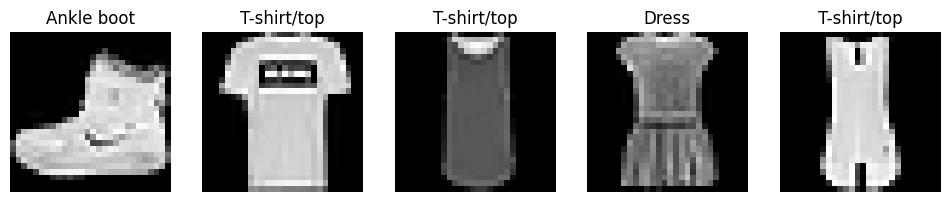

In [41]:
# 입문자 주석: 첫 이미지 5장과 Label(라벨) 이름을 확인해 데이터가 맞게 읽혔는지 시각적으로 점검합니다.

import matplotlib.pyplot as plt

classes = train_ds.classes
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    img, label = train_ds[i]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(classes[label])
    ax.axis("off")
plt.show()

### `fig` 설명

`matplotlib`을 사용하여 그래프를 그릴 때, 보통 두 가지 핵심 객체를 다룹니다:

1.  **Figure (그림)**: `fig` 변수가 바로 이 Figure 객체를 나타냅니다. 이것은 **전체 그림이 그려지는 창이나 페이지**에 해당합니다. 예를 들어, 그림의 크기(figsize), 제목 등을 설정하는 데 사용됩니다.
2.  **Axes (축)**: `axes` 변수는 실제 데이터가 그려지는 **그래프 영역**을 나타냅니다. 하나의 Figure 안에 여러 개의 Axes가 있을 수 있습니다. `plt.subplots()` 함수를 사용하면 Figure와 Axes 객체를 동시에 생성할 수 있습니다.

코드 셀 `777107a3`에서 `fig, axes = plt.subplots(1, 5, figsize=(12, 3))` 이 줄은 다음과 같이 작동합니다:

*   `fig`: 새로 생성된 Figure 객체입니다. 이 그림의 전체 크기는 `figsize=(12, 3)`로 설정됩니다.
*   `axes`: 이 Figure 안에 생성된 5개의 그래프(서브플롯) 영역을 담고 있는 배열(ndarray)입니다. 여기서는 1행 5열의 형태로 그래프 영역이 만들어졌습니다.

따라서 `fig`는 FashionMNIST 이미지 5개를 표시하는 전체 시각화의 '캔버스' 역할을 한다고 생각하시면 됩니다.

### transforms: 데이터 변환

#### 코드 4코드 실행

**예제 흐름:** Normalize 정의를 새로 만듭니다. 이미 만든 train_ds에는 소급 적용되지 않으므로 실제 적용 시 Dataset도 다시 만들어야 합니다.

In [44]:
# 입문자 주석: Normalize 정의를 새로 만듭니다. 이미 만든 train_ds에는 소급 적용되지 않으므로 실제 적용 시 Dataset도 다시 만들어야 합니다.

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.5], std=[0.5]),   # 0~1 -> -1~1
])

In [45]:
# 이 Transform은 새 정의이며, 이미 만든 train_ds에는 아직 적용되지 않았습니다.
print("새 Transform 정의 (기존 train_ds 미적용):")
print(transform)

새 Transform 정의 (기존 train_ds 미적용):
Compose(
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.5], std=[0.5], inplace=False)
)


### DataLoader 사용하기

#### 코드 5값 확인

**예제 흐름:** Dataset을 Batch 64개씩 묶고 첫 Batch의 이미지·라벨 Shape를 확인합니다.

In [46]:
# 입문자 주석: Dataset을 Batch 64개씩 묶고 첫 Batch의 이미지·라벨 Shape를 확인합니다.

from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

images, labels = next(iter(train_loader))
print(images.shape)   # torch.Size([64, 1, 28, 28])  배치 차원이 생김!
print(labels.shape)   # torch.Size([64])

torch.Size([64, 1, 28, 28])
torch.Size([64])


#### 코드 6값 확인

**예제 흐름:** DataLoader 전체를 한 번 순회하면 1 Epoch이며, 마지막까지 몇 Batch인지 확인합니다.

In [47]:
# 입문자 주석: DataLoader 전체를 한 번 순회하면 1 Epoch이며, 마지막까지 몇 Batch인지 확인합니다.

for images, labels in train_loader:
    pass   # 여기서 모델 학습이 일어날 예정
print("1 에폭 완료. 배치 수:", len(train_loader))   # 60000/64 = 938

1 에폭 완료. 배치 수: 938


### 실습. 데이터 파이프라인 구축

#### 원문 예제 53

> 자동 실행 제외: 같은 이름의 CSV 파일을 덮어쓸 수 있는 예제. 원문은 그대로 보존했습니다.

```python
csv_text = """study_hours,sleep_hours,passed
2,8,0
5,7,1
8,6,1
1,9,0
7,5,1
3,8,0"""
with open("study.csv", "w") as f:
    f.write(csv_text)

```

**입문자 설명:** 같은 이름의 study.csv를 덮어쓸 수 있는 File I/O(파일 입출력) 예제라 자동 실행에서 제외합니다.

In [48]:
csv_text = """study_hours,sleep_hours,passed
2,8,0
5,7,1
8,6,1
1,9,0
7,5,1
3,8,0"""
with open("study.csv", "w") as f:
    f.write(csv_text)


### 실습: 데이터 파이프라인 구축

1. 50개 샘플의 Custom Dataset과 Batch size 8 DataLoader를 만들고 첫·마지막 Batch Shape를 확인합니다.
2. FashionMNIST 클래스별 이미지를 한 장씩 시각화합니다.
3. shuffle=True와 False에서 첫 Batch 순서가 어떻게 달라지는지 비교합니다.
4. Normalize 전후 이미지의 min·max·mean을 비교합니다.
5. 아래 CSV 예제를 별도 안전한 폴더에서 실행해 Custom Dataset으로 읽고 Batch size 2로 순회합니다.

### 1. 50개 샘플의 Custom Dataset과 Batch size 8 DataLoader를 만들고 첫·마지막 Batch Shape 확인

In [49]:
# Custom Dataset 생성에 사용할 50개 샘플 더미 데이터 생성
X_custom = torch.rand(50, 5) # 50개 샘플, 5개 특성
y_custom = torch.randint(0, 2, (50,)) # 50개 라벨 (0 또는 1)

# SimpleDataset 클래스 재사용 (혹은 다시 정의)
class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

custom_ds = SimpleDataset(X_custom, y_custom)

# Batch size 8 DataLoader 생성
custom_loader = DataLoader(custom_ds, batch_size=8, shuffle=True)

# 첫 번째 Batch Shape 확인
first_batch_x, first_batch_y = next(iter(custom_loader))
print(f"첫 번째 Batch의 X Shape: {first_batch_x.shape}")
print(f"첫 번째 Batch의 y Shape: {first_batch_y.shape}")

# 마지막 Batch Shape 확인 (전체 데이터 수 50, batch_size 8 이므로 6번째 batch는 8개, 마지막 7번째 batch는 2개)
last_batch_x, last_batch_y = None, None
for i, (x_batch, y_batch) in enumerate(custom_loader):
    if i == len(custom_loader) - 1:
        last_batch_x, last_batch_y = x_batch, y_batch

print(f"마지막 Batch의 X Shape: {last_batch_x.shape}")
print(f"마지막 Batch의 y Shape: {last_batch_y.shape}")

첫 번째 Batch의 X Shape: torch.Size([8, 5])
첫 번째 Batch의 y Shape: torch.Size([8])
마지막 Batch의 X Shape: torch.Size([2, 5])
마지막 Batch의 y Shape: torch.Size([2])


### 2. FashionMNIST 클래스별 이미지를 한 장씩 시각화

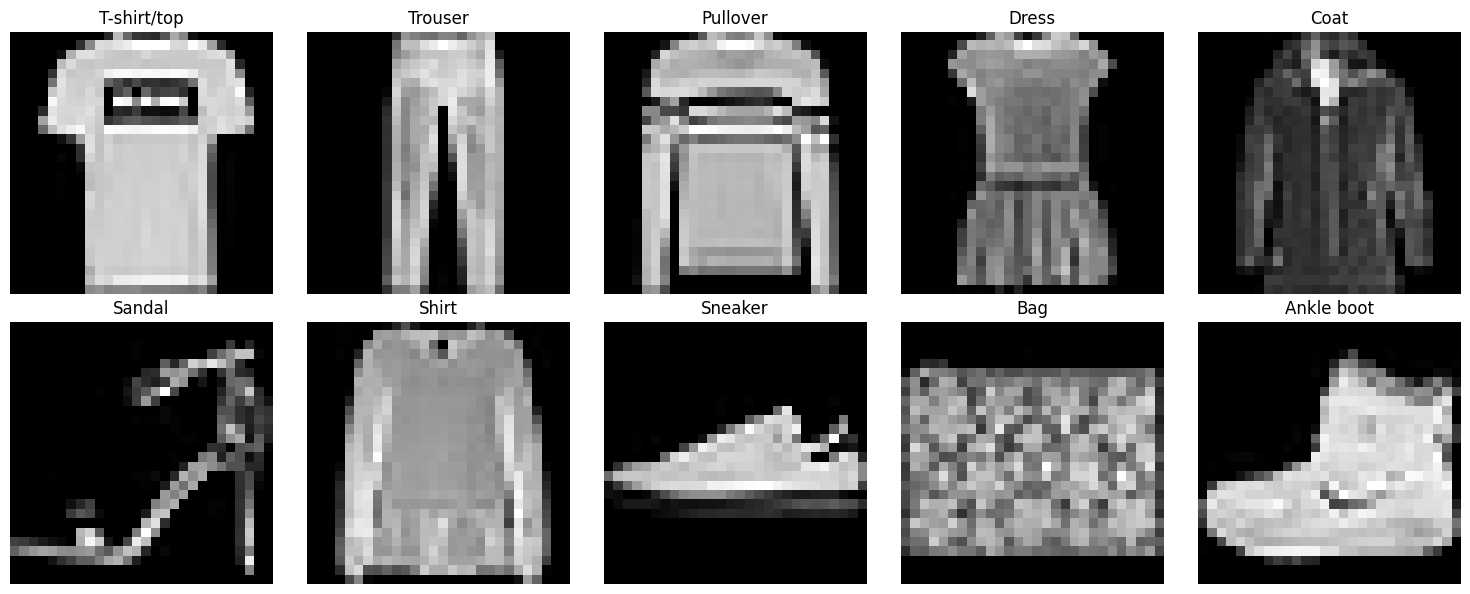

In [50]:
import matplotlib.pyplot as plt

# FashionMNIST 클래스 이름 가져오기
classes = train_ds.classes

# 각 클래스별로 첫 번째 이미지 찾아서 저장
class_images = {}
for img, label in train_ds:
    if label not in class_images:
        class_images[label] = img
    if len(class_images) == len(classes):
        break

# 클래스별 이미지 시각화
fig, axes = plt.subplots(2, 5, figsize=(15, 6)) # 총 10개 클래스, 2행 5열
axes = axes.flatten() # 2D 배열을 1D로 평탄화하여 쉽게 순회

for i, class_idx in enumerate(sorted(class_images.keys())):
    ax = axes[i]
    img = class_images[class_idx]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(classes[class_idx])
    ax.axis("off")

plt.tight_layout()
plt.show()

### 3. `shuffle=True`와 `False`에서 첫 Batch 순서가 어떻게 달라지는지 비교

In [51]:
# shuffle=True인 DataLoader
shuffled_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
# shuffle=False인 DataLoader
unshuffled_loader = DataLoader(train_ds, batch_size=4, shuffle=False)

# 각 DataLoader에서 첫 번째 Batch 가져오기
shuffled_images, shuffled_labels = next(iter(shuffled_loader))
unshuffled_images, unshuffled_labels = next(iter(unshuffled_loader))

print("--- shuffle=True 일 때 첫 번째 Batch의 Labels ---")
print(shuffled_labels)

print("\n--- shuffle=False 일 때 첫 번째 Batch의 Labels ---")
print(unshuffled_labels)

# 라벨이 다른지 확인 (보통 다름)
print("\n두 DataLoader의 첫 번째 Batch 라벨이 다른가?:", not torch.equal(shuffled_labels, unshuffled_labels))

# 첫 번째 배치의 이미지를 시각적으로 비교 (선택 사항)
# fig, axes = plt.subplots(1, 4, figsize=(10, 2))
# for i, ax in enumerate(axes):
#     ax.imshow(shuffled_images[i].squeeze(), cmap='gray')
#     ax.set_title(f'S: {shuffled_labels[i].item()}')
#     ax.axis('off')
# plt.suptitle('Shuffled Batch', y=1.05)
# plt.tight_layout()
# plt.show()

# fig, axes = plt.subplots(1, 4, figsize=(10, 2))
# for i, ax in enumerate(axes):
#     ax.imshow(unshuffled_images[i].squeeze(), cmap='gray')
#     ax.set_title(f'U: {unshuffled_labels[i].item()}')
#     ax.axis('off')
# plt.suptitle('Unshuffled Batch', y=1.05)
# plt.tight_layout()
# plt.show()

--- shuffle=True 일 때 첫 번째 Batch의 Labels ---
tensor([6, 9, 7, 8])

--- shuffle=False 일 때 첫 번째 Batch의 Labels ---
tensor([9, 0, 0, 3])

두 DataLoader의 첫 번째 Batch 라벨이 다른가?: True


### 4. Normalize 전후 이미지의 min·max·mean 비교

In [52]:
from torchvision.transforms import v2

# Normalize 적용 전 이미지 (기존 train_ds에서 가져옴, 0~1 범위)
raw_img, _ = train_ds[0]
print("--- Normalize 전 이미지 ---")
print(f"Min: {raw_img.min():.4f}")
print(f"Max: {raw_img.max():.4f}")
print(f"Mean: {raw_img.mean():.4f}")

# Normalize 변환 정의 (0~1 -> -1~1 범위로)
normalize_transform = v2.Normalize(mean=[0.5], std=[0.5])

# 이미지에 Normalize 적용
normalized_img = normalize_transform(raw_img)

print("\n--- Normalize 후 이미지 (mean=0.5, std=0.5) ---")
print(f"Min: {normalized_img.min():.4f}") # (0-0.5)/0.5 = -1
print(f"Max: {normalized_img.max():.4f}") # (1-0.5)/0.5 = 1
print(f"Mean: {normalized_img.mean():.4f}")

--- Normalize 전 이미지 ---
Min: 0.0000
Max: 1.0000
Mean: 0.3814

--- Normalize 후 이미지 (mean=0.5, std=0.5) ---
Min: -1.0000
Max: 1.0000
Mean: -0.2372


### 5. CSV 예제를 Custom Dataset으로 읽고 Batch size 2로 순회

In [53]:
import pandas as pd

# 이미 'study.csv' 파일은 준비되어 있으므로, 파일을 읽습니다.
csv_file_path = "study.csv"
df = pd.read_csv(csv_file_path)

print("--- CSV 파일 내용 ---")
print(df)

# CSV 데이터를 처리할 Custom Dataset 정의
# 이 예제에서는 입력(study_hours, sleep_hours)과 타겟(passed)을 분리합니다.
class StudyDataset(Dataset):
    def __init__(self, dataframe):
        # 입력 특성 (study_hours, sleep_hours)
        self.X = torch.tensor(dataframe[['study_hours', 'sleep_hours']].values, dtype=torch.float32)
        # 타겟 라벨 (passed)
        self.y = torch.tensor(dataframe['passed'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# StudyDataset 인스턴스 생성
study_ds = StudyDataset(df)

# Batch size 2 DataLoader 생성
study_loader = DataLoader(study_ds, batch_size=2, shuffle=False) # 순서 유지를 위해 shuffle=False

print("\n--- Batch size 2로 DataLoader 순회 --- ")
for i, (features, labels) in enumerate(study_loader):
    print(f"Batch {i+1}:")
    print(f"  Features Shape: {features.shape}, Labels Shape: {labels.shape}")
    print(f"  Features: {features}")
    print(f"  Labels: {labels}")

--- CSV 파일 내용 ---
   study_hours  sleep_hours  passed
0            2            8       0
1            5            7       1
2            8            6       1
3            1            9       0
4            7            5       1
5            3            8       0

--- Batch size 2로 DataLoader 순회 --- 
Batch 1:
  Features Shape: torch.Size([2, 2]), Labels Shape: torch.Size([2])
  Features: tensor([[2., 8.],
        [5., 7.]])
  Labels: tensor([0., 1.])
Batch 2:
  Features Shape: torch.Size([2, 2]), Labels Shape: torch.Size([2])
  Features: tensor([[8., 6.],
        [1., 9.]])
  Labels: tensor([1., 0.])
Batch 3:
  Features Shape: torch.Size([2, 2]), Labels Shape: torch.Size([2])
  Features: tensor([[7., 5.],
        [3., 8.]])
  Labels: tensor([1., 0.])


## 7. 학습 루프 완성

**흐름:** 데이터·모델 준비 → Train(학습) 함수 → Evaluate(평가) 함수 → 여러 Epoch(에폭) 반복 →
학습 곡선과 예측 확인.

매 Batch마다 Forward(순전파) → Loss → zero_grad → Backward(역전파) → step의 다섯 단계를 반복합니다.

### 학습 루프의 해부도

#### 원문 예제 54

> 자동 실행 제외: 실행 코드가 아닌 학습 순서 의사 코드. 원문은 그대로 보존했습니다.

```text
매 배치마다:
  1. forward     pred = model(x)          예측
  2. loss        loss = loss_fn(pred, y)  얼마나 틀렸나
  3. zero_grad   optimizer.zero_grad()    이전 그래디언트 청소
  4. backward    loss.backward()          미분 계산
  5. step        optimizer.step()         파라미터 업데이트

```

**입문자 설명:** 학습 Batch 하나에서 반드시 지켜야 할 다섯 단계의 순서를 코드 모양으로 요약합니다.

### 준비: 데이터, 모델, 손실, 옵티마이저

#### 코드 1코드 실행

**예제 흐름:** FashionMNIST, MLP 모델, CrossEntropyLoss, Adam을 한 번에 준비해 학습 출발 상태를 만듭니다.

In [ ]:
# 입문자 주석: FashionMNIST, MLP 모델, CrossEntropyLoss, Adam을 한 번에 준비해 학습 출발 상태를 만듭니다.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. 데이터
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])
train_ds = datasets.FashionMNIST(root="data", train=True,  download=True, transform=transform)
test_ds  = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

# 2. 모델
model = nn.Sequential(
    nn.Flatten(),              # (B, 1, 28, 28) -> (B, 784)
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)                   # 모델을 GPU로

# 3. 손실 함수와 옵티마이저
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 학습 직전의 핵심 객체를 한 줄로 점검합니다.
print(
    f"학습 준비 완료 | device={device} | "
    f"train={len(train_ds)} | test={len(test_ds)} | "
    f"batch_size={train_loader.batch_size} | "
    f"parameters={sum(parameter.numel() for parameter in model.parameters())} | "
    f"optimizer={type(optimizer).__name__} | "
    f"lr={optimizer.param_groups[0]['lr']}"
)

### 학습 함수 작성

#### 코드 2모델 학습

**예제 흐름:** Train mode에서 각 Batch를 Device로 옮기고 다섯 학습 단계를 실행한 뒤 평균 Loss를 반환합니다.

In [ ]:
# 입문자 주석: Train mode에서 각 Batch를 Device로 옮기고 다섯 학습 단계를 실행한 뒤 평균 Loss를 반환합니다.

def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()                          # 학습 모드
    total_loss = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)  # 데이터도 GPU로

        pred = model(x)                    # 1. forward
        loss = loss_fn(pred, y)            # 2. loss

        optimizer.zero_grad()              # 3. 그래디언트 초기화
        loss.backward()                    # 4. backward
        optimizer.step()                   # 5. 파라미터 업데이트

        total_loss += loss.item()          # .item(): 텐서 -> 파이썬 숫자

    return total_loss / len(loader)

### 평가 함수 작성

#### 코드 3코드 실행

**예제 흐름:** Eval mode와 no_grad로 Parameter를 바꾸지 않고 평균 Loss와 Accuracy(정확도)를 계산합니다.

In [ ]:
# 입문자 주석: Eval mode와 no_grad로 Parameter를 바꾸지 않고 평균 Loss와 Accuracy(정확도)를 계산합니다.

def evaluate(model, loader, loss_fn, device):
    model.eval()                           # 평가 모드
    total_loss, correct = 0.0, 0

    with torch.no_grad():                  # 미분 추적 끄기
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            total_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(dim=1) == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

### 전체 학습 실행

#### 코드 4값 확인

**예제 흐름:** 5 Epoch 동안 학습·평가 값을 history에 저장하고 매 Epoch 결과를 출력합니다.

In [ ]:
# 입문자 주석: 5 Epoch 동안 학습·평가 값을 history에 저장하고 매 Epoch 결과를 출력합니다.

epochs = 5
history = {"train_loss": [], "test_loss": [], "test_acc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}  "
          f"test_loss={test_loss:.4f}  test_acc={test_acc:.4f}")

#### 코드 5그림 그리기

**예제 흐름:** history의 Train/Test Loss와 Test Accuracy를 그려 학습 진행과 과적합 신호를 읽습니다.

In [ ]:
# 입문자 주석: history의 Train/Test Loss와 Test Accuracy를 그려 학습 진행과 과적합 신호를 읽습니다.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["test_loss"], label="test")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(history["test_acc"])
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Test Accuracy")
plt.show()

### 모델 저장과 불러오기

#### 원문 예제 60

> 자동 실행 제외: 같은 이름의 모델 파일을 덮어쓸 수 있는 예제. 원문은 그대로 보존했습니다.

```python
# 저장
torch.save(model.state_dict(), "fashion_model.pt")

# 불러오기: 같은 구조의 모델을 먼저 만든 뒤 파라미터를 채움
new_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
new_model.load_state_dict(torch.load("fashion_model.pt", weights_only=True))
new_model.eval()

# 저장 전 모델과 같은 성능인지 확인
_, acc = evaluate(new_model, test_loader, loss_fn, device)
print(f"불러온 모델 정확도: {acc:.4f}")
```

**입문자 설명:** state_dict만 저장하고 같은 구조의 새 모델에 불러오는 예제입니다. 같은 파일명을 덮어쓸 수 있어 자동 실행하지 않습니다.

In [ ]:
# 저장
torch.save(model.state_dict(), "fashion_model.pt")

# 불러오기: 같은 구조의 모델을 먼저 만든 뒤 파라미터를 채움
new_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
new_model.load_state_dict(torch.load("fashion_model.pt", weights_only=True))
new_model.eval()

# 저장 전 모델과 같은 성능인지 확인
_, acc = evaluate(new_model, test_loader, loss_fn, device)
print(f"불러온 모델 정확도: {acc:.4f}")

checkpoint = {
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
}
torch.save(checkpoint, "checkpoint.pt")

#### 원문 예제 61

> 자동 실행 제외: 같은 이름의 Checkpoint 파일을 덮어쓸 수 있는 예제. 원문은 그대로 보존했습니다.

```python
checkpoint = {
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
}
torch.save(checkpoint, "checkpoint.pt")
```

**입문자 설명:** Model과 Optimizer 상태, Epoch를 함께 저장하는 Checkpoint 예제입니다. 파일 덮어쓰기를 막기 위해 자동 실행하지 않습니다.

### 내 모델로 예측해 보기

#### 코드 8그림 그리기

**예제 흐름:** Test Batch에서 예측한 클래스와 실제 클래스를 이미지 5장 위에 함께 표시합니다.

In [ ]:
# 입문자 주석: Test Batch에서 예측한 클래스와 실제 클래스를 이미지 5장 위에 함께 표시합니다.

model.eval()
classes = test_ds.classes

x, y = next(iter(test_loader))
with torch.no_grad():
    pred = model(x.to(device)).argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(x[i].squeeze(), cmap="gray")
    color = "blue" if pred[i] == y[i] else "red"
    ax.set_title(f"pred: {classes[pred[i]]}\ntrue: {classes[y[i]]}", color=color)
    ax.axis("off")
plt.show()

### 실습: 학습 루프 변형

1. Epoch를 10으로 늘리고 학습 곡선을 비교합니다.
2. Learning rate(학습률)를 0.1로 바꿔 변화를 관찰합니다.
3. zero_grad를 주석 처리해 Gradient 누적 영향을 확인합니다.
4. Hidden Layer(은닉층)를 512로 늘리거나 Layer를 하나 더 추가해 Parameter 수와 Accuracy를 비교합니다.
5. SGD와 Adam의 5 Epoch 곡선을 같은 그래프에 그립니다.
6. 저장·재시작·불러오기 뒤 Accuracy가 유지되는지 확인합니다.
7. Test Accuracy 90% 이상을 목표로 바꾼 값과 이유를 기록합니다.

## 8. 미니 챌린지

**흐름:** 학습 루프의 세 빈칸을 스스로 채움 → 핵심 개념을 말로 설명할 수 있는지 점검.

이 절은 새 개념보다 지금까지의 연결 관계를 확인하는 Review(복습)입니다.

### 빈칸 채우기: 학습 루프 완성

#### 원문 예제 63

> 자동 실행 제외: 학습자가 채우는 빈칸이 남아 있는 Challenge(도전) 코드. 원문은 그대로 보존했습니다.

```python
model.train()
for x, y in train_loader:
    x, y = x.to(device), y.to(device)

    pred = ______(A)______          # 예측
    loss = loss_fn(pred, y)

    optimizer.______(B)______       # 이전 그래디언트 청소
    loss.______(C)______            # 미분 계산
    optimizer.step()
```

**입문자 설명:** 빈칸 A, B, C가 남아 있어 그대로는 Python 문법이 아닙니다. model(x), zero_grad(), backward()를 연결해 완성합니다.

### 자가 점검 Checklist(체크리스트)

- Tensor Shape를 왜 먼저 확인하는지 설명할 수 있다.
- reshape와 permute의 차이를 설명할 수 있다.
- Broadcasting의 성공·실패 조건을 안다.
- 학습이 “Loss를 줄이는 방향으로 Parameter를 움직이는 일”임을 설명할 수 있다.
- Forward와 Backward가 계산하는 내용을 구분한다.
- zero_grad가 필요한 이유를 안다.
- nn.Module의 <code>__init__</code>과 <code>forward</code> 규칙을 안다.
- Activation Function이 필요한 이유를 설명할 수 있다.
- Regression과 Classification의 대표 Loss를 구분한다.
- Dataset과 DataLoader의 역할을 구분한다.
- 학습 루프 다섯 단계를 순서대로 쓸 수 있다.
- 학습 곡선에서 Overfitting(과적합) 신호를 찾을 수 있다.

## 9. 마치며: 자주 만나는 에러 5선

**흐름:** 오류 메시지의 마지막 줄 확인 → Shape → Device → dtype → Memory(메모리) → Gradient 순서로 진단.

아래 오류 문장은 실행 예제가 아니라, 실제로 만났을 때 원인과 해결 방향을 연결하기 위한 참고 자료입니다.

#### 원문 예제 64

> 자동 실행 제외: 실행 코드가 아닌 오류 메시지. 원문은 그대로 보존했습니다.

```text
RuntimeError: mat1 and mat2 shapes cannot be multiplied (32x784 and 128x10)

```

**입문자 설명:** 입력의 마지막 크기와 Linear의 in_features가 맞지 않는 Shape mismatch입니다.

#### 원문 예제 65

> 자동 실행 제외: 실행 코드가 아닌 오류 메시지. 원문은 그대로 보존했습니다.

```text
RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

```

**입문자 설명:** 모델과 데이터가 CPU·CUDA로 나뉜 Device mismatch입니다. 모두 같은 device로 옮깁니다.

#### 원문 예제 66

> 자동 실행 제외: 실행 코드가 아닌 오류 메시지. 원문은 그대로 보존했습니다.

```text
RuntimeError: expected scalar type Float but found Long

```

**입문자 설명:** 입력 dtype이 연산이 기대하는 dtype과 다릅니다. 입력은 보통 float, CrossEntropy 정답은 long을 사용합니다.

#### 원문 예제 67

> 자동 실행 제외: 실행 코드가 아닌 오류 메시지. 원문은 그대로 보존했습니다.

```text
torch.OutOfMemoryError: CUDA out of memory.

```

**입문자 설명:** CUDA Memory가 부족합니다. 먼저 batch_size를 줄이고 Tensor 그래프를 불필요하게 보관하는지 확인합니다.

#### 원문 예제 68

> 자동 실행 제외: 실행 결과를 설명하는 진단 한 줄. 원문은 그대로 보존했습니다.

```python
print(x.grad)   # None

```

**입문자 설명:** requires_grad, backward 호출 여부, detach 또는 no_grad로 그래프가 끊겼는지를 차례로 확인합니다.

### 부록 : 로컬 환경 설치

#### 원문 예제 69

> 자동 실행 제외: Python이 아닌 Terminal 명령. 원문은 그대로 보존했습니다.

```bash
conda create -n pytorch-env python=3.11
conda activate pytorch-env

```

**입문자 설명:** 별도 Conda Environment(환경)를 만드는 Terminal(터미널) 명령입니다.

#### 원문 예제 70

> 자동 실행 제외: Python이 아닌 설치 Terminal 명령. 원문은 그대로 보존했습니다.

```bash
# 예시: pip, CUDA 12.x 환경
pip install torch torchvision

# CPU만 사용하는 경우
pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu

```

**입문자 설명:** PyTorch와 torchvision을 설치하는 Terminal 명령입니다. 실제 설치 명령은 공식 사이트에서 현재 환경에 맞춰 확인합니다.

#### 원문 예제 71

> 자동 실행 제외: Python이 아닌 NVIDIA Terminal 명령. 원문은 그대로 보존했습니다.

```bash
nvidia-smi        # 드라이버와 GPU 인식 확인

```

**입문자 설명:** NVIDIA Driver(드라이버)와 GPU 인식 상태를 확인하는 Terminal 명령입니다.

#### 원문 예제 72

> 자동 실행 제외: CUDA가 없는 Mac에서는 마지막 줄이 실패하는 CUDA 전용 확인 코드. 원문은 그대로 보존했습니다.

```python
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
```

**입문자 설명:** CUDA GPU 이름까지 확인하는 예제입니다. CUDA가 없는 Mac에서는 마지막 줄이 오류라 자동 실행하지 않습니다.

## Checks(전체 실행 점검)

아래 셀은 앞 절에서 실제로 만들어진 Dataset, DataLoader, 학습 History, 예측 Model이 기본 조건을 만족하는지 확인합니다.

In [ ]:

# FashionMNIST 원본 크기를 확인합니다.
assert len(train_ds) == 60_000
assert len(test_ds) == 10_000

# Batch의 첫 차원은 최대 64이고, 이미지 한 장은 (1, 28, 28)입니다.
assert images.ndim == 4
assert images.shape[1:] == (1, 28, 28)
assert images.shape[0] <= 64

# 5 Epoch의 학습·평가 기록이 모두 남았는지 확인합니다.
assert epochs == 5
assert len(history["train_loss"]) == epochs
assert len(history["test_loss"]) == epochs
assert len(history["test_acc"]) == epochs
assert all(0.0 <= accuracy <= 1.0 for accuracy in history["test_acc"])

# 마지막 분류 Model은 이미지 Batch를 클래스 10개의 Logit으로 바꿉니다.
with torch.no_grad():
    check_output = model(torch.zeros(2, 1, 28, 28).to(device))
assert check_output.shape == (2, 10)

print("1~9 전체 실행 점검을 통과했습니다.")

## Next Steps(다음 단계)

1. 2·3번 실습에서는 코드를 실행하기 전에 결과 Shape를 먼저 적습니다.
2. 4번에서는 Gradient 누적과 zero_grad 제거 실험을 비교합니다.
3. 7번에서는 한 번에 하나의 값만 바꿔 Epoch, Learning rate, Optimizer 영향을 비교합니다.
4. 오류가 나면 마지막 줄부터 읽고 Shape → Device → dtype 순서로 확인합니다.